# 04 - Diagnostics and Figures  (Stage 4)

**Purpose.** Produce the pathway map, seasonal & interannual fractions, transit
time distributions, centroid map (day 50 / 100 / 150), and the pathway summary
table for the chosen `k`.

**Input.** `data/labeled_trajectories.parquet` (Stage 3), the chosen k-means
model, the saved `scaler.pkl`, and the original Zarr stores (for full trajectory
paths / transit times).
**Output.** PNGs in `figures/` and a printed summary table.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # project root: config.py, pipeline.py
import numpy as np
import pandas as pd
import config as C
import pipeline as P
print("project root:", C.PROJECT_ROOT)
print("sampling days:", C.DAYS, "| feature space:", C.FEATURE_SPACE)
import cartopy.crs as ccrs, cartopy.feature as cfeature
from matplotlib.lines import Line2D
import xarray as xr
from tqdm import tqdm

project root: /work/bk1450/b383184/Amazon/Mercator/notebooks/Analysis/kmeans_analysis/kmean_analysis_30_180_stdZ_w
sampling days: [30, 50, 100, 150, 180] | feature space: zscore


**Raw clusters vs. merged groups.** Set `LABEL_COL = "cluster_group"` to make
every figure at the merged-pathway level (requires a `GROUP_MAP` in `config`),
or `"cluster_label"` for the raw k-means clusters. Everything below keys off
`LABEL_COL`, so the figures, fractions and table all follow your choice.

In [2]:
BEST_K = 50                   # <-- must match notebook 03 (papermill: -p BEST_K <k>)
LABEL_COL = "cluster_group"    # "cluster_group" (merged) or "cluster_label" (raw)

In [3]:
import pickle, matplotlib.pyplot as plt
lab = pd.read_parquet(C.LABELED_FILE)
with open(C.MODELS_DIR / f"kmeans_k{BEST_K}.pkl", "rb") as f:
    km = pickle.load(f)
with open(C.MODELS_DIR / "scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
# Per-day weighting the model was fit in (config.DAY_WEIGHTS). Centroids live in
# WEIGHTED standardized space, so divide by W to undo the weighting BEFORE
# inverse_transform gives back real degrees (mirrors notebook 02).
W = P.feature_weight_vector()
labelled = lab[lab[LABEL_COL] >= 0].copy()
n_lab = int(labelled[LABEL_COL].max()) + 1
cmap = plt.get_cmap("tab20", max(n_lab, 3))

# Centroids in real degrees: [lat50, lon50, lat100, lon100, lat150, lon150] per label.
# (inverse_transform of the standardized k-means centres, via the saved scaler).
raw_cent = P.centroids_to_degrees(km.cluster_centers_ / W, scaler)
if LABEL_COL == "cluster_group" and C.GROUP_MAP:
    _, raw2grp = P.apply_group_map(np.arange(BEST_K), C.GROUP_MAP, BEST_K)
    sizes = lab.loc[lab.cluster_label >= 0, "cluster_label"].value_counts()
    # Merge in the WEIGHTED standardized space (size-weighted mean of the
    # weighted centres), then divide by W and inverse-transform -> a proper
    # group centroid in degrees.
    dim = km.cluster_centers_.shape[1]
    grp_centers = np.zeros((n_lab, dim)); wsum = np.zeros(n_lab)
    for c in range(BEST_K):
        g = raw2grp[c]; w = float(sizes.get(c, 0))
        grp_centers[g] += km.cluster_centers_[c] * w; wsum[g] += w
    grp_centers /= np.where(wsum[:, None] == 0, 1, wsum[:, None])
    disp_cent = P.centroids_to_degrees(grp_centers / W, scaler)
else:
    disp_cent = raw_cent
LABEL_NAMES = C.GROUP_NAMES if LABEL_COL == "cluster_group" else {}
print(f"labelled trajectories: {len(labelled):,} | {LABEL_COL}: {n_lab} labels")

labelled trajectories: 16,160,000 | cluster_group: 7 labels


## Figure 1 - Pathway map

Plot up to ~5,000 *full* trajectories per cluster, coloured by label. Full paths
are streamed from the Zarr stores so we never hold everything in memory. We pick
a random set of `trajectory_id`s per cluster, group them by store, and read only
those rows.

In [4]:
rng = np.random.default_rng(C.RANDOM_STATE)

# choose <= C.PLOT_SAMPLE_PER_LABEL trajectory_ids per label (raw cluster or
# merged group); a label with fewer than that uses all of them.
n_plot = C.PLOT_SAMPLE_PER_LABEL
pick = (labelled.groupby(LABEL_COL, group_keys=False)
        .apply(lambda d: d.sample(min(n_plot, len(d)), random_state=C.RANDOM_STATE)))
pick = pick[["trajectory_id", LABEL_COL]].rename(columns={LABEL_COL: "lab"}).copy()
pick["store_index"] = pick.trajectory_id // C.TRAJ_PER_STORE
pick["local"] = pick.trajectory_id % C.TRAJ_PER_STORE
stores = C.list_stores()
print(f"sampling up to {n_plot:,} trajectories/label -> {len(pick):,} total for plotting")

sampling up to 5,000 trajectories/label -> 35,000 total for plotting


/tmp/ipykernel_734986/241572734.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d.sample(min(n_plot, len(d)), random_state=C.RANDOM_STATE)))


In [5]:
# --- Read each needed store ONCE, in parallel, cache in memory --------------
# `pick` lists exactly which trajectories we need (store_index / local), so each
# store is opened a SINGLE time and only those rows kept. Figs 1, 1b and 4 then
# draw from these dicts -> the Zarr is read once, not three times.
#
# Parallelism: this loop is I/O-bound (Zarr reads), NOT CPU-bound. numba can't
# help -- it JITs numeric Python, it cannot compile/parallelize xarray/disk I/O.
# The right tool is a THREAD pool: zarr/blosc decompression releases the GIL, so
# threads overlap disk latency. The per-store math is trivial vectorized NumPy.
#
# Transit time to 10N uses obs_index * 0.25 day: output is 6-hourly (verified --
# 7.4M of 7.4M steps are exactly 6 h), so days-since-release = j * 0.25 and we
# skip reading `time` entirely (~1/3 less I/O). It's a per-particle RELATIVE
# offset, so different release dates across stores are irrelevant.
from joblib import Parallel, delayed

LAT_THRESH    = 10.0
OBS_STEP_DAYS = 0.25     # 6-hourly output -> obs j is j*0.25 days since release
N_IO_THREADS  = 16       # tune to the node / filesystem (you have 32 cpus)

def _read_store(si, grp):
    ds  = xr.open_zarr(stores[si])
    loc = grp.local.to_numpy()
    lon = ds.lon.values[loc].astype("float32")     # (n_in_store, obs)
    lat = ds.lat.values[loc].astype("float32")
    rel_days = np.arange(lat.shape[1]) * OBS_STEP_DAYS
    crossed  = (lat >= LAT_THRESH) & ~np.isnan(lat)
    t10 = np.where(crossed, rel_days[None, :], np.inf).min(axis=1)
    t10[np.isinf(t10)] = np.nan
    return grp.trajectory_id.to_numpy(), lon, lat, t10

groups  = list(pick.groupby("store_index"))
results = Parallel(n_jobs=N_IO_THREADS, backend="threading")(
    delayed(_read_store)(si, grp) for si, grp in tqdm(groups))

paths, transit = {}, {}      # tid -> (lon[obs], lat[obs]) ;  tid -> days to 10N
for tids, lon, lat, t10 in results:
    for k, tid in enumerate(tids):
        paths[int(tid)]   = (lon[k], lat[k])
        transit[int(tid)] = float(t10[k])
pick["t10N"] = pick.trajectory_id.map(transit)
print(f"cached {len(paths):,} trajectories from {pick.store_index.nunique()} stores")


100%|██████████| 1616/1616 [01:16<00:00, 21.21it/s]


cached 35,000 trajectories from 1616 stores


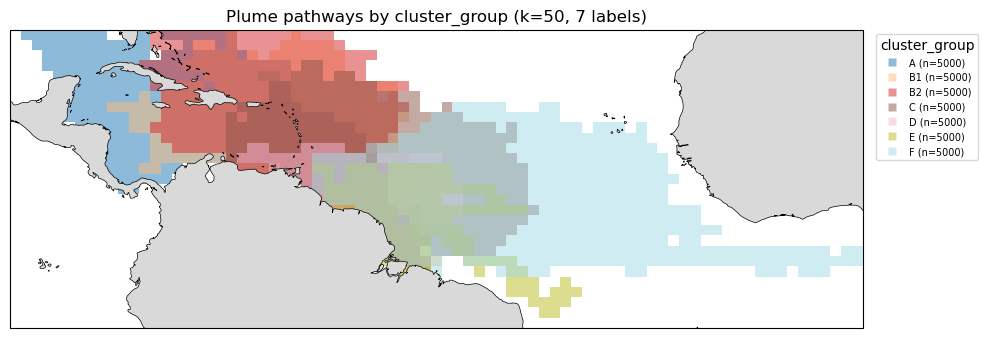

In [15]:
from matplotlib.colors import ListedColormap

# --- Occupancy footprint per label ------------------------------------------
# Bin cached positions into a lon/lat grid, SKIPPING obs 0 (the release point,
# like the seminar code) so the source cell doesn't dominate. The combined map
# overlays each label as its own SOLID colour at alpha 0.5 (no sequential /
# divergent ramp) so overlapping footprints blend. Computed once, reused by 1b.
lon_bins = np.linspace(C.DOMAIN["lon_min"], C.DOMAIN["lon_max"], 80)   # 79 cells
lat_bins = np.linspace(C.DOMAIN["lat_min"], C.DOMAIN["lat_max"], 30)   # 29 cells

xs = {c: [] for c in range(n_lab)}; ys = {c: [] for c in range(n_lab)}
for tid, lab in zip(pick.trajectory_id.to_numpy(), pick.lab.to_numpy()):
    lon, lat = paths[int(tid)]
    xs[lab].append(lon[1:]); ys[lab].append(lat[1:])       # drop obs 0 (release)
Hlab = np.zeros((n_lab, lat_bins.size - 1, lon_bins.size - 1))         # (label, lat, lon)
for c in range(n_lab):
    x = np.concatenate(xs[c]); y = np.concatenate(ys[c])
    m = ~(np.isnan(x) | np.isnan(y))
    h, _, _ = np.histogram2d(x[m], y[m], bins=[lon_bins, lat_bins])
    Hlab[c] = h.T                                                      # -> (lat, lon)

fig = plt.figure(figsize=(11, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([C.DOMAIN["lon_min"], C.DOMAIN["lon_max"],
               C.DOMAIN["lat_min"], C.DOMAIN["lat_max"]], crs=ccrs.PlateCarree())
for c in range(n_lab):
    footprint = np.where(Hlab[c] > 0, 1.0, np.nan)         # occupied cells only
    ax.pcolormesh(lon_bins, lat_bins, footprint, cmap=ListedColormap([cmap(c)]),
                  vmin=0, vmax=1, alpha=.5, transform=ccrs.PlateCarree(), zorder=1)
ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=2); ax.coastlines(lw=.5, zorder=3)
handles = [Line2D([0], [0], marker="s", ls="", mec="none", alpha=.5, mfc=cmap(c),
                  label=f"{LABEL_NAMES.get(c, c)} (n={int((pick.lab == c).sum())})")
           for c in range(n_lab)]
ax.legend(handles=handles, title=LABEL_COL, fontsize=7, loc="upper left", bbox_to_anchor=(1.01, 1))
ax.set_title(f"Plume pathways by {LABEL_COL} (k={BEST_K}, {n_lab} labels)")
fig.savefig(C.FIG_DIR / f"pathway_map_k{BEST_K}_{LABEL_COL}.png", dpi=140, bbox_inches="tight")
plt.show()

## Figure 1b - Pathway map, one panel per label

The combined map above overlaps every pathway; here the **same** sampled
trajectories are split so each `LABEL_COL` (cluster or merged group) gets its own
panel. All panels share the map `DOMAIN` extent so they can be compared directly,
and each panel keeps its label's colour (title tinted to match).

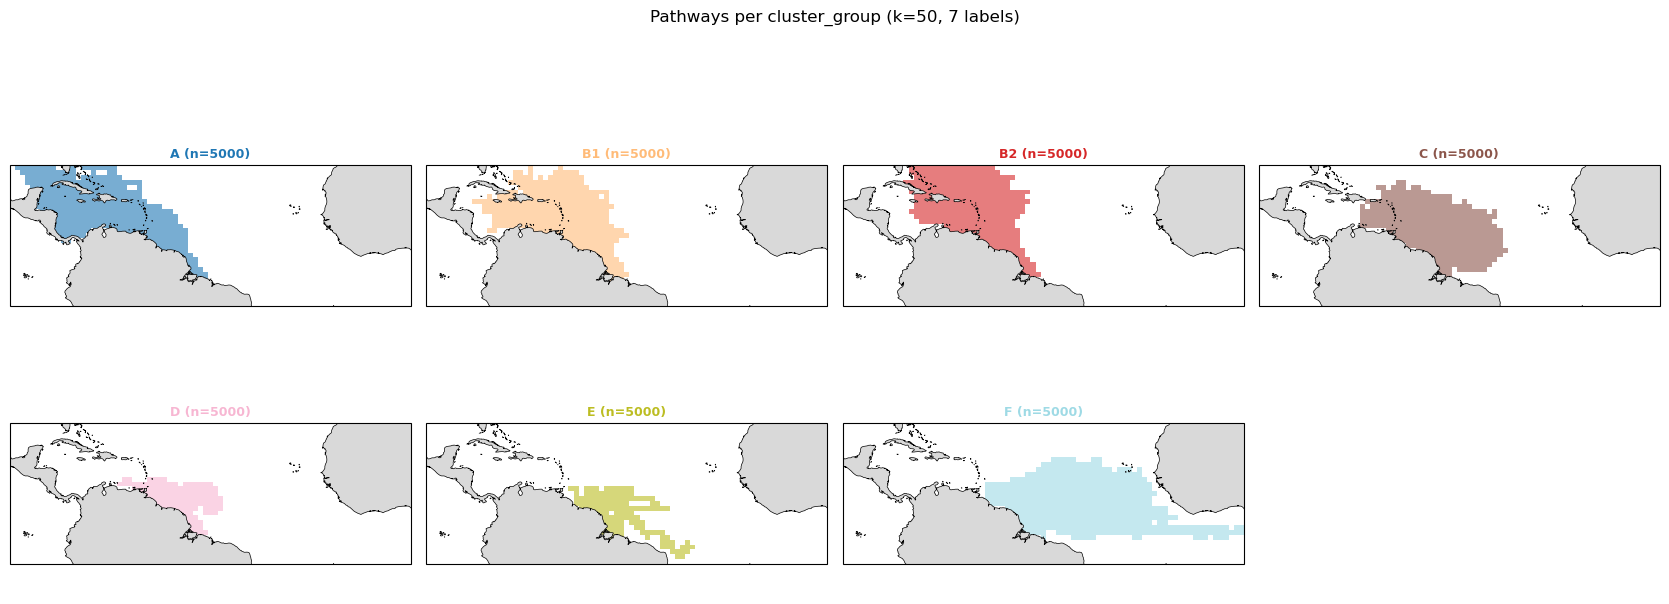

In [16]:
# Per-label footprint (small multiples): one panel per label, its occupied cells
# filled in that label's solid colour. Reuses `Hlab` / `lon_bins` / `lat_bins`
# from Fig 1 (obs 0 already dropped). Same shared extent so panels compare.
from matplotlib.colors import ListedColormap

ncol = min(n_lab, 4)
nrow = int(np.ceil(n_lab / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.4 * nrow),
                         subplot_kw={"projection": ccrs.PlateCarree()}, squeeze=False)
axflat = axes.ravel()
for c in range(n_lab):
    ax = axflat[c]
    ax.set_extent([C.DOMAIN["lon_min"], C.DOMAIN["lon_max"],
                   C.DOMAIN["lat_min"], C.DOMAIN["lat_max"]], crs=ccrs.PlateCarree())
    footprint = np.where(Hlab[c] > 0, 1.0, np.nan)
    ax.pcolormesh(lon_bins, lat_bins, footprint, cmap=ListedColormap([cmap(c)]),
                  vmin=0, vmax=1, alpha=.6, transform=ccrs.PlateCarree(), zorder=1)
    ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=2); ax.coastlines(lw=.5, zorder=3)
    ax.set_title(f"{LABEL_NAMES.get(c, c)} (n={int((pick.lab == c).sum())})",
                 fontsize=9, color=cmap(c), fontweight="bold")

for k in range(n_lab, nrow * ncol):       # blank any unused panels
    axflat[k].axis("off")
fig.suptitle(f"Pathways per {LABEL_COL} (k={BEST_K}, {n_lab} labels)", y=1.0, fontsize=12)
fig.tight_layout()
fig.savefig(C.FIG_DIR / f"pathway_maps_by_{LABEL_COL}_k{BEST_K}.png", dpi=130, bbox_inches="tight")
plt.show()

## Figure 2 - Seasonal pathway fractions (stacked bars by release month)

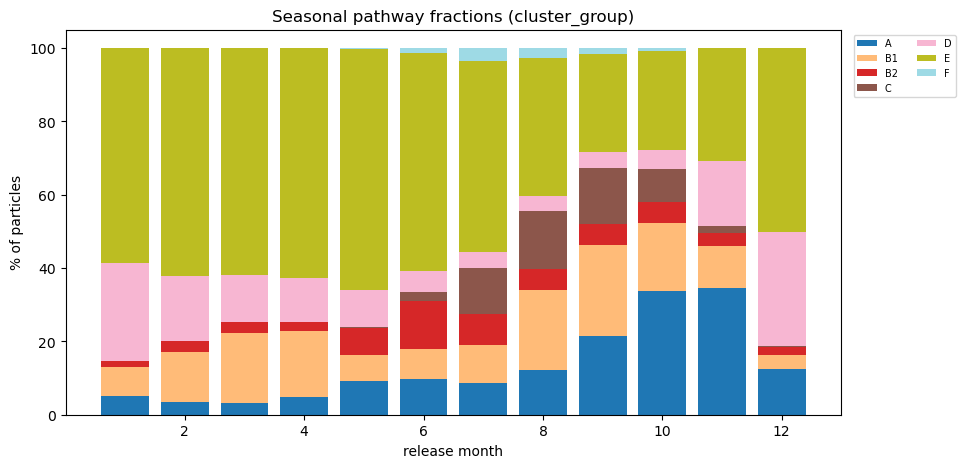

In [17]:
def label_name(c):
    return LABEL_NAMES.get(c, str(c))

def fraction_table(group_col):
    g = labelled.groupby([group_col, LABEL_COL]).size().unstack(fill_value=0)
    return g.div(g.sum(axis=1), axis=0) * 100

seas = fraction_table("release_month").reindex(range(1, 13))
fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(seas))
for c in range(n_lab):
    vals = seas.get(c, pd.Series(0, index=seas.index)).to_numpy()
    ax.bar(seas.index, vals, bottom=bottom, color=cmap(c), label=label_name(c))
    bottom += vals
ax.set_xlabel("release month"); ax.set_ylabel("% of particles")
ax.set_title(f"Seasonal pathway fractions ({LABEL_COL})")
ax.legend(ncol=2, fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
fig.savefig(C.FIG_DIR / f"seasonal_fractions_k{BEST_K}_{LABEL_COL}.png", dpi=130, bbox_inches="tight")
plt.show()

## Figure 3 - Interannual pathway fractions (stacked area by release year)

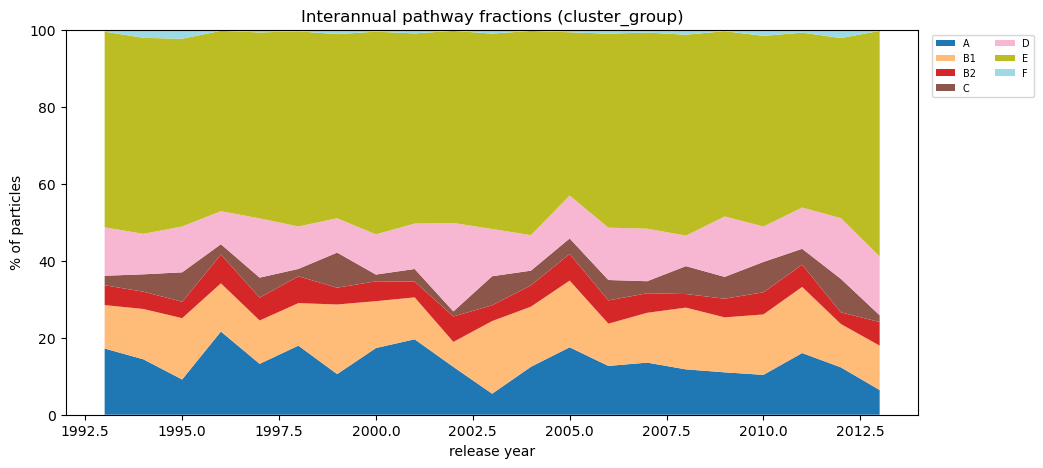

In [18]:
yr = fraction_table("release_year").sort_index()
fig, ax = plt.subplots(figsize=(11, 5))
ax.stackplot(yr.index, *[yr.get(c, pd.Series(0, index=yr.index)).to_numpy()
                         for c in range(n_lab)],
             colors=[cmap(c) for c in range(n_lab)], labels=[label_name(c) for c in range(n_lab)])
ax.set_xlabel("release year"); ax.set_ylabel("% of particles"); ax.set_ylim(0, 100)
ax.set_title(f"Interannual pathway fractions ({LABEL_COL})")
ax.legend(ncol=2, fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
fig.savefig(C.FIG_DIR / f"interannual_fractions_k{BEST_K}_{LABEL_COL}.png", dpi=130, bbox_inches="tight")
plt.show()

## Figure 4 - Transit-time distributions per cluster

Time (days since release) to first reach 10°N, computed from the Zarr stores via
`pipeline.first_crossing_days`. We reuse the per-cluster `pick` sample from
Figure 1 to keep the I/O bounded.

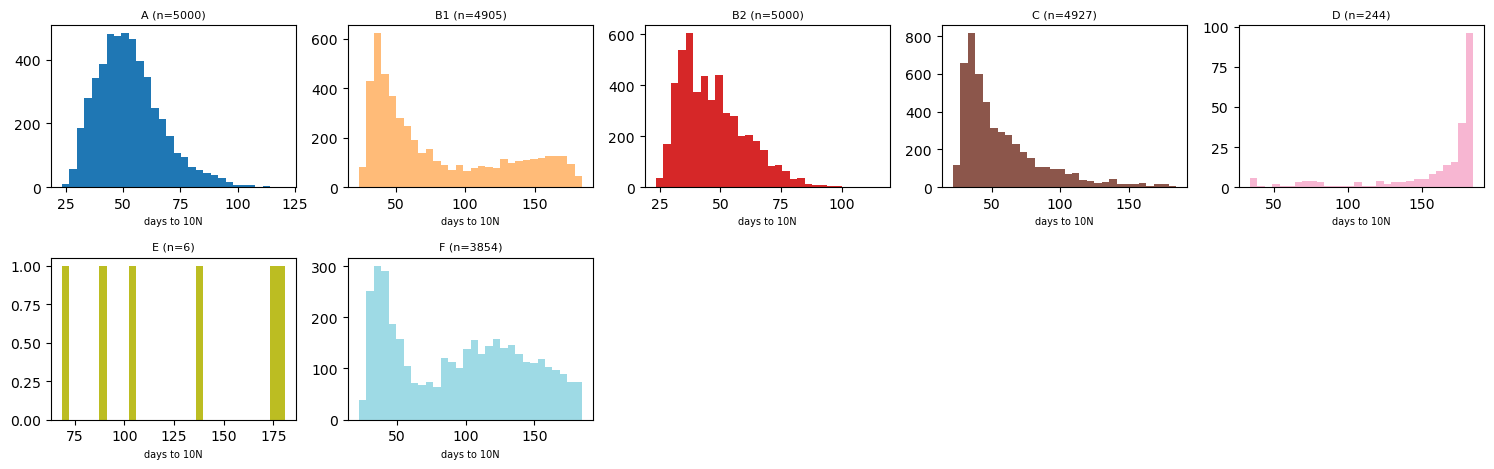

In [19]:
# pick["t10N"] (days since release to first reach 10N) was already computed in
# the single-read cache cell above, so there is no Zarr read here.
ncol = 5; nrow = int(np.ceil(n_lab / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3*ncol, 2.4*nrow), squeeze=False)
for c in range(n_lab):
    ax = axes[c // ncol][c % ncol]
    d = pick.loc[pick.lab == c, "t10N"].dropna()
    ax.hist(d, bins=30, color=cmap(c))
    ax.set_title(f"{label_name(c)} (n={len(d)})", fontsize=8)
    ax.set_xlabel("days to 10N", fontsize=7)
for j in range(n_lab, nrow*ncol):
    axes[j // ncol][j % ncol].axis("off")
fig.tight_layout()
fig.savefig(C.FIG_DIR / f"transit_time_histograms_k{BEST_K}_{LABEL_COL}.png", dpi=120)
plt.show()

## Figure 5 - Centroid positions (marker per sampling day, joined by a line)

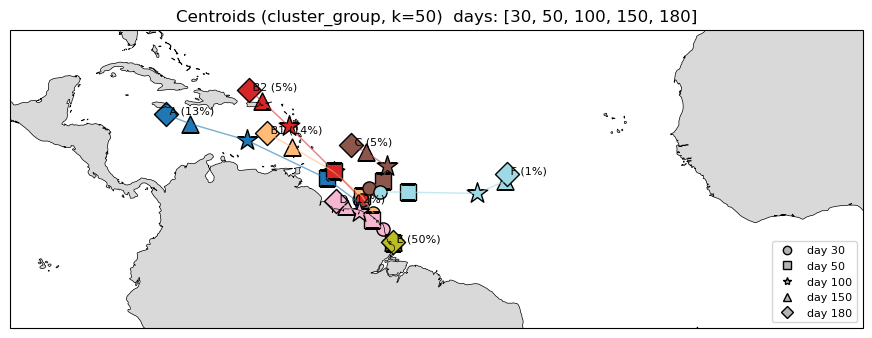

In [20]:
cent = disp_cent   # per label: [lat_d0, lon_d0, lat_d1, lon_d1, ...] real degrees
pct = labelled[LABEL_COL].value_counts(normalize=True).sort_index() * 100
day_markers = ["o", "s", "*", "^", "D", "P"]
day_sizes   = [90, 120, 240, 150, 150, 150]
fig = plt.figure(figsize=(11, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([C.DOMAIN["lon_min"], C.DOMAIN["lon_max"],
               C.DOMAIN["lat_min"], C.DOMAIN["lat_max"]], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="0.85"); ax.coastlines(lw=.5)
for c in range(n_lab):
    lats = cent[c, 0::2]; lons = cent[c, 1::2]      # one entry per day in C.DAYS
    ax.plot(lons, lats, "-", color=cmap(c), lw=1, alpha=.6, transform=ccrs.PlateCarree())
    for j in range(len(C.DAYS)):
        ax.scatter(lons[j], lats[j], color=cmap(c), s=day_sizes[j % len(day_sizes)],
                   marker=day_markers[j % len(day_markers)], edgecolor="k",
                   transform=ccrs.PlateCarree())
    ax.text(lons[-1], lats[-1], f" {label_name(c)} ({pct.get(c,0):.0f}%)", fontsize=8,
            transform=ccrs.PlateCarree())
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], marker=day_markers[j % len(day_markers)], color="k",
                  ls="", mfc="0.7", label=f"day {d}") for j, d in enumerate(C.DAYS)]
ax.legend(handles=handles, loc="lower right", fontsize=8)
ax.set_title(f"Centroids ({LABEL_COL}, k={BEST_K})  days: {list(C.DAYS)}")
fig.savefig(C.FIG_DIR / f"centroids_k{BEST_K}_{LABEL_COL}.png", dpi=140, bbox_inches="tight")
plt.show()

## Table 1 - Pathway summary

In [21]:
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
last_day = C.DAYS[-1]
rows = []
for c in range(n_lab):
    sel = labelled[labelled[LABEL_COL] == c]
    peak = month_names[int(sel.release_month.mode().iloc[0]) - 1] if len(sel) else "-"
    mt = pick.loc[pick.lab == c, "t10N"].dropna()
    rows.append(dict(
        label=c,
        name=LABEL_NAMES.get(c, ""),
        pct=round(len(sel) / len(labelled) * 100, 1),
        peak_month=peak,
        mean_transit_10N=round(float(mt.mean()), 1) if len(mt) else np.nan,
        mean_lat_last=round(float(sel[f"lat_{last_day}"].mean()), 2),
        mean_lon_last=round(float(sel[f"lon_{last_day}"].mean()), 2),
    ))
summary = pd.DataFrame(rows)
summary.to_csv(C.DATA_DIR / f"pathway_summary_k{BEST_K}_{LABEL_COL}.csv", index=False)
print(f"(mean_lat_last / mean_lon_last are the day-{last_day} positions)")
print(summary.to_string(index=False))

(mean_lat_last / mean_lon_last are the day-180 positions)
 label name  pct peak_month  mean_transit_10N  mean_lat_last  mean_lon_last
     0    A 13.2        Oct              52.7          17.04         -76.65
     1   B1 13.8        Sep              80.6          14.73         -64.61
     2   B2  5.2        Jun              46.9          19.85         -66.92
     3    C  4.9        Aug              57.1          13.29         -54.92
     4    D 12.4        Dec             158.4           6.81         -56.65
     5    E 49.6        May             125.9           2.11         -50.13
     6    F  0.9        Jul              94.7          10.09         -36.41


## Table 2 - Top-20 representative particles per cluster

For each `LABEL_COL` (raw cluster or merged group) we pick the **20 trajectories
whose feature vector is closest to that label's centroid** — the most
"typical" / representative members of the cluster.

Distances are measured in the *exact space k-means was fit in*: raw positions
`[lat_d, lon_d]` for every day in `C.DAYS`, standardized by the saved `scaler`
and then multiplied by the per-day weight vector `W` (`config.DAY_WEIGHTS`).
Centroids are taken in that same space (`km.cluster_centers_` for
`cluster_label`; the size-weighted `grp_centers` for `cluster_group`), so the
"closest" ranking is consistent with how the clusters were formed.

**Output.** `data/top20_representatives_k{BEST_K}_{LABEL_COL}.csv`.


In [22]:
N_REP = 20   # representatives to keep per cluster

# --- Per-label centroids in the WEIGHTED-standardized space k-means was fit in.
#   cluster_label -> the raw k-means centres (already in that space).
#   cluster_group -> `grp_centers` (size-weighted merge, built in the setup cell).
if LABEL_COL == "cluster_group" and C.GROUP_MAP:
    cent_model = grp_centers                      # (n_lab, dim), weighted std space
else:
    cent_model = km.cluster_centers_[:n_lab]      # (n_lab, dim)

# --- Every labelled particle -> the SAME weighted-standardized feature space.
# build_feature_matrix gives raw degrees; scaler standardizes; *W applies the
# per-day weighting. This mirrors the fit/predict path in notebooks 02 / 03.
Xw = scaler.transform(P.build_feature_matrix(labelled)) * W          # (N, dim)

# --- Euclidean distance of each particle to ITS label's centroid. -----------
labels_arr = labelled[LABEL_COL].to_numpy()
diff = Xw - cent_model[labels_arr]
labelled["dist_to_centroid"] = np.sqrt(np.einsum("ij,ij->i", diff, diff))

# --- Keep the N_REP smallest-distance particles per label, ranked 1..N_REP. --
# NB exclude LABEL_COL from id_cols so it isn't duplicated (it is already the
# first column below); a duplicate column makes `reps[[.., LABEL_COL]]` 2-D.
id_cols  = [c for c in ("trajectory_id", "cluster_label", "cluster_group",
                         "release_year", "release_month")
            if c in labelled.columns and c != LABEL_COL]
deg_cols = P.feature_columns()                    # lat_d / lon_d in real degrees
reps = (labelled
        .sort_values("dist_to_centroid")
        .groupby(LABEL_COL, group_keys=False)
        .head(N_REP)
        .sort_values([LABEL_COL, "dist_to_centroid"])
        .copy())
reps["name"] = reps[LABEL_COL].map(lambda c: LABEL_NAMES.get(c, str(c)))
reps["rank"] = reps.groupby(LABEL_COL).cumcount() + 1
reps = reps[[LABEL_COL, "name", "rank", "dist_to_centroid", *id_cols, *deg_cols]]

out_csv = C.DATA_DIR / f"top{N_REP}_representatives_k{BEST_K}_{LABEL_COL}.csv"
reps.to_csv(out_csv, index=False)
print(f"wrote {len(reps):,} rows ({N_REP} per {LABEL_COL}) -> {out_csv}")
print(reps.groupby("name").size().rename("n_reps").to_string())
reps.head(N_REP)


wrote 140 rows (20 per cluster_group) -> /work/bk1450/b383184/Amazon/Mercator/notebooks/Analysis/kmeans_analysis/kmean_analysis_30_180_stdZ_w/data/top20_representatives_k50_cluster_group.csv
name
A     20
B1    20
B2    20
C     20
D     20
E     20
F     20


,cluster_group,name,rank,dist_to_centroid,trajectory_id,cluster_label,release_year,release_month,lat_30,lon_30,lat_50,lon_50,lat_100,lon_100,lat_150,lon_150,lat_180,lon_180
6135902,0,A,1,0.353422,6135902,45,2001,6,6.287521,-53.925743,9.159470,-58.266006,12.952676,-67.514946,16.016619,-74.498543,17.145174,-76.703712
7145975,0,A,2,0.368237,7145975,45,2002,11,6.683794,-53.849869,9.220199,-58.421204,13.915751,-68.278717,16.596590,-72.929031,16.952328,-77.200790
535945,0,A,3,0.385739,535945,13,1993,9,7.238060,-53.984077,9.504030,-58.193031,13.913471,-67.860321,17.193945,-74.070076,16.862352,-75.467094
7145419,0,A,4,0.387556,7145419,45,2002,11,6.768998,-53.941147,9.167525,-58.485817,13.792002,-68.333687,16.190979,-73.584206,16.708372,-76.996078
14986008,0,A,5,0.388399,14986008,13,2011,11,6.123270,-53.509888,10.165754,-58.092262,14.055062,-66.839561,14.865619,-75.591904,16.896303,-76.958397
2852812,0,A,6,0.389013,2852812,13,1996,12,6.756142,-53.640717,9.821744,-57.693916,14.692982,-67.918610,15.906136,-73.206116,16.456625,-74.828651
14979604,0,A,7,0.390981,14979604,13,2011,11,7.070745,-54.379505,9.168924,-57.543919,13.392611,-67.398056,16.073372,-73.381920,16.468580,-76.812088
7143911,0,A,8,0.403590,7143911,45,2002,11,6.722206,-53.942696,9.182105,-58.439995,13.902547,-68.303879,17.161915,-73.786079,17.224985,-76.385635
6345105,0,A,9,0.404870,6345105,13,2001,10,6.495575,-53.421265,9.631101,-57.814251,13.454546,-65.499214,15.435111,-73.354630,16.726236,-77.591537
14989482,0,A,10,0.405396,14989482,13,2011,11,6.169914,-53.590904,10.114893,-58.232117,14.574330,-67.244186,14.367589,-74.050751,16.661648,-76.640190


### Representative trajectories - map (one panel per cluster)

The full paths of the `N_REP` representatives are streamed from the Zarr stores
(same single-read-per-store trick as Figure 1) and drawn as thin lines in the
label's colour, one panel per `LABEL_COL`. The centroid's day-by-day track
(`disp_cent`, real degrees) is overlaid in black so you can see how tightly the
representatives hug the cluster centre. A star marks each particle's release
point.


read full paths for 140 representative trajectories


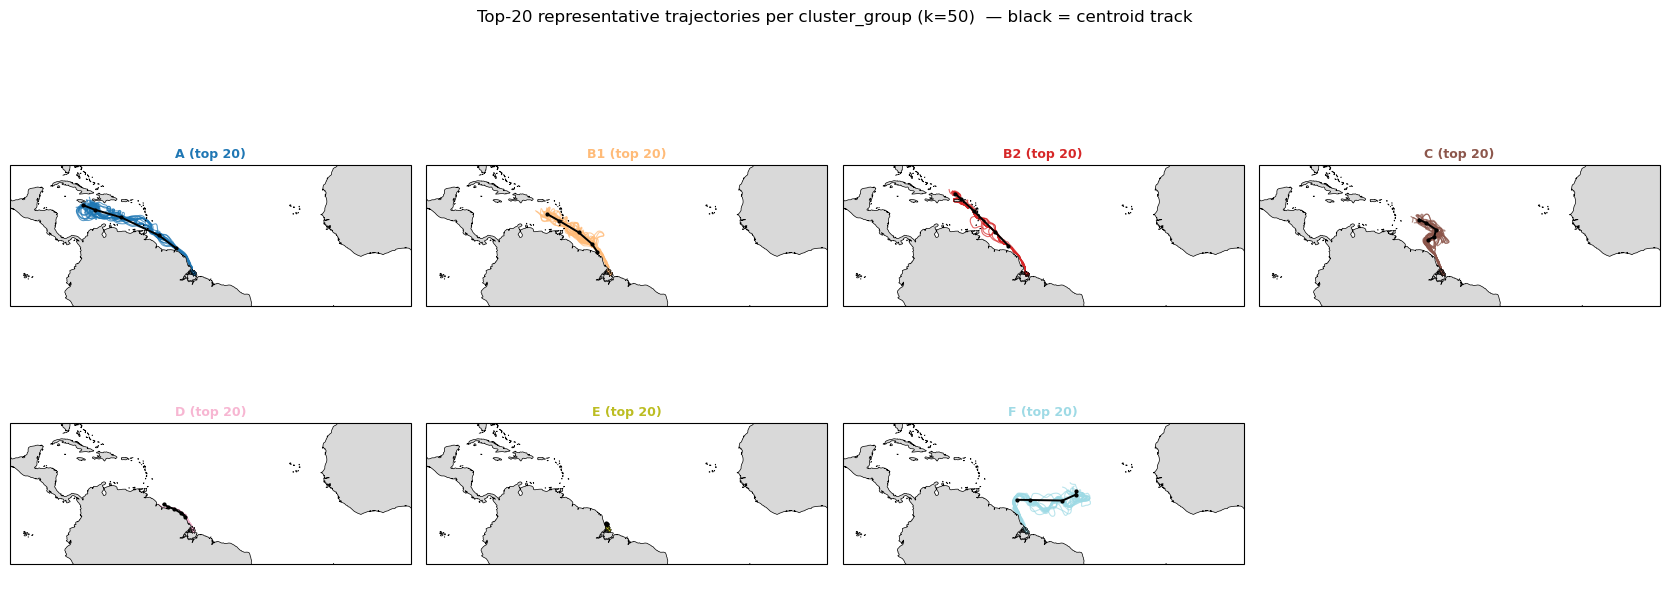

In [25]:
# --- Stream the FULL paths of the representative trajectories from Zarr. -----
# Same idea as Fig 1: open each store once, keep only the rows we need. The rep
# set is tiny (N_REP * n_lab), so this is fast.
rep_pick = reps[["trajectory_id", LABEL_COL]].rename(columns={LABEL_COL: "lab"}).copy()
rep_pick["store_index"] = rep_pick.trajectory_id // C.TRAJ_PER_STORE
rep_pick["local"]       = rep_pick.trajectory_id % C.TRAJ_PER_STORE

def _read_paths(si, grp):
    ds  = xr.open_zarr(stores[si])
    loc = grp.local.to_numpy()
    lon = ds.lon.values[loc].astype("float32")
    lat = ds.lat.values[loc].astype("float32")
    return grp.trajectory_id.to_numpy(), lon, lat

rep_res = Parallel(n_jobs=N_IO_THREADS, backend="threading")(
    delayed(_read_paths)(si, grp) for si, grp in rep_pick.groupby("store_index"))
rep_paths = {}
for tids, lon, lat in rep_res:
    for k, tid in enumerate(tids):
        rep_paths[int(tid)] = (lon[k], lat[k])
print(f"read full paths for {len(rep_paths):,} representative trajectories")

# --- Small multiples: one panel per label, its N_REP representatives + centroid.
ncol = min(n_lab, 4)
nrow = int(np.ceil(n_lab / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.4 * nrow),
                         subplot_kw={"projection": ccrs.PlateCarree()}, squeeze=False)
axflat = axes.ravel()
for c in range(n_lab):
    ax = axflat[c]
    ax.set_extent([C.DOMAIN["lon_min"], C.DOMAIN["lon_max"],
                   C.DOMAIN["lat_min"], C.DOMAIN["lat_max"]], crs=ccrs.PlateCarree())
    for tid in rep_pick.loc[rep_pick.lab == c, "trajectory_id"]:
        lon, lat = rep_paths[int(tid)]
        m = ~(np.isnan(lon) | np.isnan(lat))       # drop NaN tail (tracks that ended early)
        lon, lat = lon[m], lat[m]
        if lon.size == 0:
            continue
        ax.plot(lon, lat, "-", color=cmap(c), lw=.8, alpha=.7, transform=ccrs.PlateCarree())
        ax.scatter(lon[0], lat[0], color=cmap(c), s=10, marker="*",
                   edgecolor="k", lw=.3, zorder=4, transform=ccrs.PlateCarree())
    clat = disp_cent[c, 0::2]; clon = disp_cent[c, 1::2]      # centroid track (degrees)
    ax.plot(clon, clat, "-o", color="k", lw=1.4, ms=2, zorder=5, transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=2); ax.coastlines(lw=.5, zorder=3)
    ax.set_title(f"{LABEL_NAMES.get(c, c)} (top {N_REP})", fontsize=9,
                 color=cmap(c), fontweight="bold")
for k in range(n_lab, nrow * ncol):
    axflat[k].axis("off")
fig.suptitle(f"Top-{N_REP} representative trajectories per {LABEL_COL} "
             f"(k={BEST_K})  — black = centroid track", y=1.0, fontsize=12)
fig.tight_layout()
fig.savefig(C.FIG_DIR / f"top{N_REP}_representatives_k{BEST_K}_{LABEL_COL}.png",
            dpi=130, bbox_inches="tight")
plt.show()
